# **Tree-Based AI modelling - XGBoost**



**Structure of the notebook:**

**Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv**

**Step 2 - Naive baseline model (persistence / seasonal-naive)**

**Step 3 - Baseline model (with default hyperparameters)**

**Step 4 - Hyperparameters tuning**

**Step 5 - Final model training**

**Step 6 - Evaluation (different metrics)**

**Step 7 - SHAP explainability**

**Step 8 - Save the trained model + test prediction results**

**Additional I - Baseline size/latency/complexity metrics (for Model Compression comparison)**

**Additional II - Bias and Mitigation Analysis**

(Remark: Source datasets (train/val/test are from previous EDA process outputs.

   Files are stored in github: https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main)



In [1]:
# Read the EDA-generated splits directly from GitHub (public repo, no auth needed);
# save this notebook's own outputs (figures, model, predictions, metadata) to a local Colab folder.
import os
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main"
PROCESSED_DIR = f"{BASE_URL}/data/processed"   # read: split datasets from the EDA notebook

OUTPUT_DIR = "outputs/xgboost"                  # write: figures, trained model, predictions, metadata
os.makedirs(OUTPUT_DIR, exist_ok=True)


# **Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv**


In [2]:
# Step 1 - Load splitted datasets - split_train.csv / split_val.csv / split_test.csv

import pandas as pd
import numpy as np
import random

# 1. Set random seed for reproducibility (important for fair comparison against LSTM later)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 2. Load the three splits, parsing the date column back into a datetime index
#    (these were saved with 'date' as the index in Phase 8, so parse it back the same way)
train = pd.read_csv(f'{PROCESSED_DIR}/split_train.csv', index_col='date', parse_dates=True)
val = pd.read_csv(f'{PROCESSED_DIR}/split_val.csv', index_col='date', parse_dates=True)
test = pd.read_csv(f'{PROCESSED_DIR}/split_test.csv', index_col='date', parse_dates=True)

# 3. Sanity checks: shapes, date ranges, no overlap, no unexpected NaNs
print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({train.shape[0]} rows, {train.shape[1]} cols)")
print(f"Val:   {val.index.min().date()} to {val.index.max().date()}  ({val.shape[0]} rows, {val.shape[1]} cols)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}  ({test.shape[0]} rows, {test.shape[1]} cols)")

assert train.index.max() < val.index.min(), "Train/validation overlap detected"
assert val.index.max() < test.index.min(), "Validation/test overlap detected"

print("\nNaN check (should all be 0):")
print(pd.concat([train.isna().sum(), val.isna().sum(), test.isna().sum()], axis=1,
                 keys=['train', 'val', 'test']).sum(axis=1).sort_values(ascending=False).head())

# 4. Separate features (X) and target (y) for each split
target_col = 'nd_total_mwh'

X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_val, y_val = val.drop(columns=[target_col]), val[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"\nFeature columns ({X_train.shape[1]}):")
print(X_train.columns.tolist())

# 5. Confirm XGBoost is available and check version (worth recording in your report's methodology)
import xgboost as xgb
print(f"\nXGBoost version: {xgb.__version__}")

Train: 2009-01-31 to 2021-12-31  (4718 rows, 21 cols)
Val:   2022-01-01 to 2022-12-31  (365 rows, 21 cols)
Test:  2023-01-01 to 2024-06-11  (528 rows, 21 cols)

NaN check (should all be 0):
nd_total_mwh    0
is_holiday      0
min_temp °c     0
max_temp °c     0
rain mm         0
dtype: int64

X_train: (4718, 20), X_val: (365, 20), X_test: (528, 20)

Feature columns (20):
['is_holiday', 'min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h', 'StringencyIndex_Average', 'is_weekend', 'hdd', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_7', 'demand_roll_mean_7', 'demand_roll_mean_30', 'demand_roll_std_7', 'hdd_x_weekend']

XGBoost version: 3.3.0


# **Step 2 - Naive baseline model (persistence / seasonal-naive)**

In [3]:
# Step 2 - Naive baseline model (persistence / seasonal-naive)

import numpy as np

# 1. Persistence baseline: predict using yesterday's demand
#    (already engineered as demand_lag_1 in Phase 7, sitting in X_test)
y_pred_persistence = X_test['demand_lag_1']

# 2. Seasonal-naive baseline: predict using demand from 365 days earlier
#    Test starts 2023-01-01, so the first ~365 test rows need demand values
#    reaching back into 2022 (the validation set) - concatenate the full
#    nd_total_mwh series across all three splits before shifting, then select test only
full_demand = pd.concat([train['nd_total_mwh'], val['nd_total_mwh'], test['nd_total_mwh']])
y_pred_seasonal_naive = full_demand.shift(365).loc[test.index]

# 3. Evaluation function (reused for every model in this notebook, including the final one)
def evaluate(y_true, y_pred, label):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:25s}  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  MAPE={mape:>6.2f}%")
    return {'label': label, 'mae': mae, 'rmse': rmse, 'mape': mape}

print("Naive baseline performance on test set:\n")
results_persistence = evaluate(y_test, y_pred_persistence, "Persistence (t-1)")
results_seasonal = evaluate(y_test, y_pred_seasonal_naive, "Seasonal-naive (t-365)")

# 4. Quick sanity check: confirm no NaNs leaked into the seasonal-naive predictions
#    (would indicate the concatenated series didn't reach back far enough)
print(f"\nNaN count in seasonal-naive predictions: {y_pred_seasonal_naive.isna().sum()}")

Naive baseline performance on test set:

Persistence (t-1)          MAE=    36,064  RMSE=    46,999  MAPE=  5.87%
Seasonal-naive (t-365)     MAE=    50,508  RMSE=    64,891  MAPE=  8.08%

NaN count in seasonal-naive predictions: 0


# **Step 3 - Baseline model (with default hyperparameters)**

In [4]:
# Step 3 - Baseline model (with default hyperparameters)

import time
from xgboost import XGBRegressor

# 1. Instantiate XGBoost with library defaults (no tuning yet)
baseline_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=SEED,
    n_jobs=-1
)

# 2. Train on the training set only
start_time = time.time()
baseline_model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# 3. Evaluate on train (sanity check for gross overfitting) and validation
#    (test set stays untouched until Step 6 - the final, single evaluation)
y_pred_train = baseline_model.predict(X_train)
y_pred_val = baseline_model.predict(X_val)

print("\nDefault-hyperparameter XGBoost performance:\n")
results_baseline_train = evaluate(y_train, y_pred_train, "Baseline (train)")
results_baseline_val = evaluate(y_val, y_pred_val, "Baseline (validation)")

# 4. Quick comparison against the naive baselines from Step 2
print(f"\nFor reference - Step 2 naive baselines were evaluated on the TEST set, not validation.")
print(f"A fair head-to-head against XGBoost will be done in Step 6 (final evaluation),")
print(f"using the same test set for both the naive baselines and the tuned model.")

# 5. Default hyperparameters actually used - corrected to show the true defaults
booster_config = baseline_model.get_booster().save_config()
import json
config_dict = json.loads(booster_config)
train_params = config_dict['learner']['gradient_booster']['tree_train_param']
print("Actual default hyperparameters used (from the fitted booster):")
for key in ['max_depth', 'eta', 'subsample', 'colsample_bytree', 'min_child_weight', 'lambda', 'alpha']:
    if key in train_params:
        print(f"  {key}: {train_params[key]}")
print(f"  n_estimators (num_boost_round): {baseline_model.get_booster().num_boosted_rounds()}")

Training time: 1.16 seconds

Default-hyperparameter XGBoost performance:

Baseline (train)           MAE=     3,962  RMSE=     5,270  MAPE=  0.52%
Baseline (validation)      MAE=    23,258  RMSE=    30,157  MAPE=  3.78%

For reference - Step 2 naive baselines were evaluated on the TEST set, not validation.
A fair head-to-head against XGBoost will be done in Step 6 (final evaluation),
using the same test set for both the naive baselines and the tuned model.
Actual default hyperparameters used (from the fitted booster):
  max_depth: 6
  eta: 0.300000012
  subsample: 1
  colsample_bytree: 1
  min_child_weight: 1
  lambda: 1
  alpha: 0
  n_estimators (num_boost_round): 100


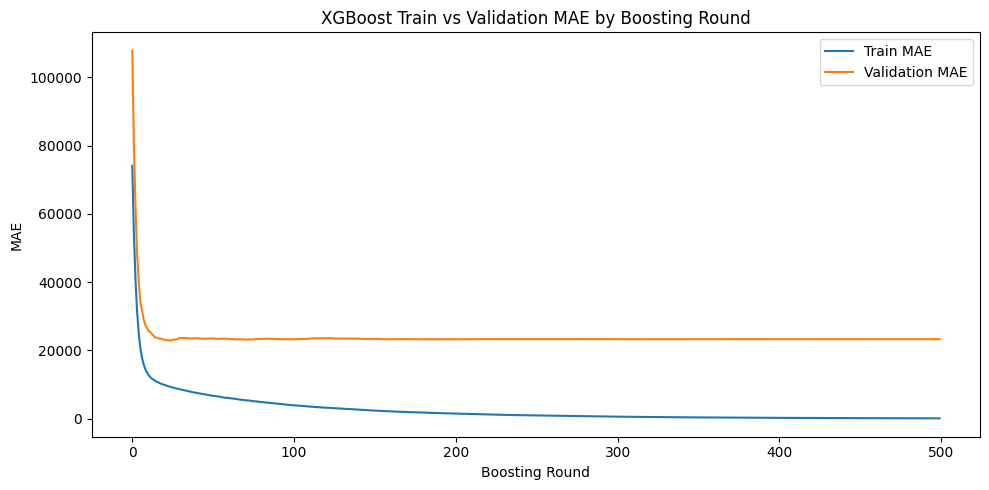

In [5]:
# Visual plot to check overfitting signal
# XGBoost equivalent of the TensorBoard train/val curve check

eval_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='mae'
)

eval_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Extract the per-round train/val metric history (the direct analog of TensorBoard's curves)
results = eval_model.evals_result()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['mae'], label='Train MAE')
plt.plot(results['validation_1']['mae'], label='Validation MAE')
plt.xlabel('Boosting Round')
plt.ylabel('MAE')
plt.title('XGBoost Train vs Validation MAE by Boosting Round')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_train_val_curve.png', dpi=150)
plt.show()



Overfitting check.  

The curve shows:

Validation MAE bottoms out and plateaus almost immediately — by roughly round 20 - 30

Train MAE keeps declining all the way to round 500, ending up near zero.

Overfitting --> early stopping needed.


# **Step 4 - Hyperparameters tuning**

In [6]:
# Step 4 - Hyperparameters tuning (broad random search over an expanded space)

import itertools
import random as pyrandom
import time
import pandas as pd
from xgboost import XGBRegressor

# Wider parameter space, specified upfront - the previous grid (max_depth 3-6, eta
# 0.01-0.3, colsample_bytree 0.7/1.0)
param_space = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'eta': [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

N_RANDOM_SAMPLES = 150  # increased from 50 - the smaller sample missed the region
                         # containing the previously-known-good combination entirely;

all_combinations = list(itertools.product(
    param_space['max_depth'], param_space['eta'],
    param_space['subsample'], param_space['colsample_bytree']
))
print(f"Full parameter space: {len(all_combinations)} combinations")

pyrandom.seed(SEED)
sampled_combinations = pyrandom.sample(all_combinations, N_RANDOM_SAMPLES)

previous_best = (3, 0.3, 1.0, 0.7)  # max_depth, eta, subsample, colsample_bytree
if previous_best not in sampled_combinations:
    sampled_combinations.append(previous_best)
    print(f"Added previously-known-good combination to guarantee no regression: {previous_best}")

tuning_start_time = time.time()
results_log = []

for max_depth, eta, subsample, colsample_bytree in sampled_combinations:
    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=500,
        max_depth=max_depth,
        eta=eta,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='mae',
        early_stopping_rounds=30
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    best_iteration = model.best_iteration
    y_pred_val = model.predict(X_val, iteration_range=(0, best_iteration + 1))
    val_mae = np.mean(np.abs(y_val - y_pred_val))
    val_mape = np.mean(np.abs((y_val - y_pred_val) / y_val)) * 100

    results_log.append({'max_depth': max_depth, 'eta': eta, 'subsample': subsample,
                         'colsample_bytree': colsample_bytree,
                         'best_n_estimators': best_iteration + 1,
                         'val_mae': val_mae, 'val_mape': val_mape})

tuning_elapsed = time.time() - tuning_start_time

results_df = pd.DataFrame(results_log).sort_values('val_mae').reset_index(drop=True)
print(f"\nStep 4 total tuning time: {tuning_elapsed:.1f}s ({tuning_elapsed/60:.2f} min)")
print("\nTop 10 hyperparameter combinations by validation MAE:\n")
print(results_df.head(10).to_string(index=False))

best_params = results_df.iloc[0][['max_depth', 'eta', 'subsample', 'colsample_bytree']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
best_n_estimators = int(results_df.iloc[0]['best_n_estimators'])

print(f"\nBest hyperparameters (by validation MAE):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  n_estimators: {best_n_estimators}")
print(f"\nBest validation MAE: {results_df.iloc[0]['val_mae']:,.0f}  "
      f"(vs. default baseline validation MAE: 23,258 from Step 3)")
print(f"Best validation MAPE: {results_df.iloc[0]['val_mape']:.2f}%  "
      f"(vs. default baseline validation MAPE: 3.78% from Step 3)")

# Automatic boundary check - confirms whether the winner sits at an edge of this wider space
print("\nBoundary check on the winning combination:")
for param, space in [('max_depth', param_space['max_depth']), ('eta', param_space['eta']),
                      ('subsample', param_space['subsample']),
                      ('colsample_bytree', param_space['colsample_bytree'])]:
    val = best_params[param]
    if val == min(space):
        print(f"  {param}={val}: AT MINIMUM of tested range - consider extending lower")
    elif val == max(space):
        print(f"  {param}={val}: AT MAXIMUM of tested range - consider extending higher")
    else:
        print(f"  {param}={val}: not at boundary - good")

Full parameter space: 1470 combinations
Added previously-known-good combination to guarantee no regression: (3, 0.3, 1.0, 0.7)

Step 4 total tuning time: 103.1s (1.72 min)

Top 10 hyperparameter combinations by validation MAE:

 max_depth  eta  subsample  colsample_bytree  best_n_estimators      val_mae  val_mape
         2 0.40        0.8               0.6                122 17704.762842  2.834089
         2 0.40        0.7               1.0                190 17996.743664  2.904738
         2 0.50        1.0               0.7                128 18128.169949  2.925397
         2 0.30        0.7               0.9                269 18154.149572  2.925982
         3 0.30        1.0               0.7                127 18334.393322  2.961913
         2 0.50        0.7               0.5                 82 18670.526027  2.957794
         2 0.20        1.0               0.5                336 18999.751455  3.084978
         2 0.30        0.8               0.8                191 19008.350856

As max_depth = 2 is on the boundary, a quick check is needed to confirm the best set of hyperparameters.

In [7]:
# Quick targeted check: does max_depth=1 continue the trend, or does max_depth=2 mark a genuine floor?
# Testing against the top few (eta, subsample, colsample_bytree) combinations already found to work well at max_depth=2.

top_combos_at_depth2 = results_df[results_df['max_depth'] == 2].head(4)[
    ['eta', 'subsample', 'colsample_bytree']].values.tolist()

print(f"Testing max_depth=1 against top {len(top_combos_at_depth2)} combos:")
for eta, subsample, colsample_bytree in top_combos_at_depth2:
    model = XGBRegressor(
        objective='reg:squarederror', n_estimators=500, max_depth=1,
        eta=eta, subsample=subsample, colsample_bytree=colsample_bytree,
        random_state=SEED, n_jobs=-1, eval_metric='mae', early_stopping_rounds=30
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    best_iteration = model.best_iteration
    y_pred_val = model.predict(X_val, iteration_range=(0, best_iteration + 1))
    val_mae = np.mean(np.abs(y_val - y_pred_val))
    val_mape = np.mean(np.abs((y_val - y_pred_val) / y_val)) * 100
    results_log.append({'max_depth': 1, 'eta': eta, 'subsample': subsample,
                         'colsample_bytree': colsample_bytree,
                         'best_n_estimators': best_iteration + 1,
                         'val_mae': val_mae, 'val_mape': val_mape})
    print(f"depth=1 eta={eta} subsample={subsample} colsample={colsample_bytree} -> "
          f"n_est={best_iteration+1:>3}  val_MAE={val_mae:>10,.0f}  val_MAPE={val_mape:>5.2f}%")

results_df = pd.DataFrame(results_log).sort_values('val_mae').reset_index(drop=True)
print("\nUpdated top 5 (including max_depth=1 check):\n")
print(results_df.head(5).to_string(index=False))

best_params = results_df.iloc[0][['max_depth', 'eta', 'subsample', 'colsample_bytree']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
best_n_estimators = int(results_df.iloc[0]['best_n_estimators'])
print(f"\nFinal best hyperparameters: {best_params}, n_estimators={best_n_estimators}")

Testing max_depth=1 against top 4 combos:
depth=1 eta=0.4 subsample=0.8 colsample=0.6 -> n_est=259  val_MAE=    19,048  val_MAPE= 3.03%
depth=1 eta=0.4 subsample=0.7 colsample=1.0 -> n_est=243  val_MAE=    20,365  val_MAPE= 3.25%
depth=1 eta=0.5 subsample=1.0 colsample=0.7 -> n_est=231  val_MAE=    20,629  val_MAPE= 3.30%
depth=1 eta=0.3 subsample=0.7 colsample=0.9 -> n_est=269  val_MAE=    20,248  val_MAPE= 3.21%

Updated top 5 (including max_depth=1 check):

 max_depth  eta  subsample  colsample_bytree  best_n_estimators      val_mae  val_mape
         2  0.4        0.8               0.6                122 17704.762842  2.834089
         2  0.4        0.7               1.0                190 17996.743664  2.904738
         2  0.5        1.0               0.7                128 18128.169949  2.925397
         2  0.3        0.7               0.9                269 18154.149572  2.925982
         3  0.3        1.0               0.7                127 18334.393322  2.961913

Final best h

# **Step 5 - Final model training**

Note: Hyperparameters are decided in Step 4.  The final model will be re-fitted (re-trained) with train + validation set combbined.


In [8]:
# Step 5 - Final model training

import time
from xgboost import XGBRegressor

# 1. Combine train + validation
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"Combined train+validation: {X_trainval.shape[0]} rows "
      f"({X_train.shape[0]} train + {X_val.shape[0]} validation)")

# 2. Instantiate the final model
final_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_n_estimators,
    random_state=SEED,
    n_jobs=-1,
    **best_params
)

# 3. Train on the combined set
start_time = time.time()
final_model.fit(X_trainval, y_trainval)
final_train_time = time.time() - start_time
print(f"\nFinal model training time: {final_train_time:.2f} seconds")

# 4. Record the exact configuration used
print(f"\nFinal model configuration:")
print(f"  max_depth: {best_params['max_depth']}")
print(f"  eta: {best_params['eta']}")
print(f"  subsample: {best_params['subsample']}")
print(f"  colsample_bytree: {best_params['colsample_bytree']}")
print(f"  n_estimators: {best_n_estimators}")

# 5. Sanity check
y_pred_trainval_check = final_model.predict(X_trainval)
sanity_mae = np.mean(np.abs(y_trainval - y_pred_trainval_check))
print(f"\nSanity check - MAE on combined train+val (fit set, not a real evaluation metric): {sanity_mae:,.0f}")
print("(Full, proper evaluation against the held-out test set happens in Step 6)")

Combined train+validation: 5083 rows (4718 train + 365 validation)

Final model training time: 0.06 seconds

Final model configuration:
  max_depth: 2
  eta: 0.4
  subsample: 0.8
  colsample_bytree: 0.6
  n_estimators: 122

Sanity check - MAE on combined train+val (fit set, not a real evaluation metric): 13,841
(Full, proper evaluation against the held-out test set happens in Step 6)


# **Step 6 - Evaluation (different metrics)**

Final tuned XGBoost performance on TEST set:

Tuned XGBoost (test)       MAE=    29,691  RMSE=    35,014  MAPE=  4.88%

Full comparison - all evaluated on the SAME test set:

                 Model          MAE         RMSE  MAPE (%)  Improvement vs Persistence (%)
     Persistence (t-1) 36063.912879 46999.260404  5.866807                             0.0
Seasonal-naive (t-365) 50508.095644 64891.289166  8.081354                           -40.1
  Tuned XGBoost (test) 29690.637607 35013.993440  4.881104                            17.7


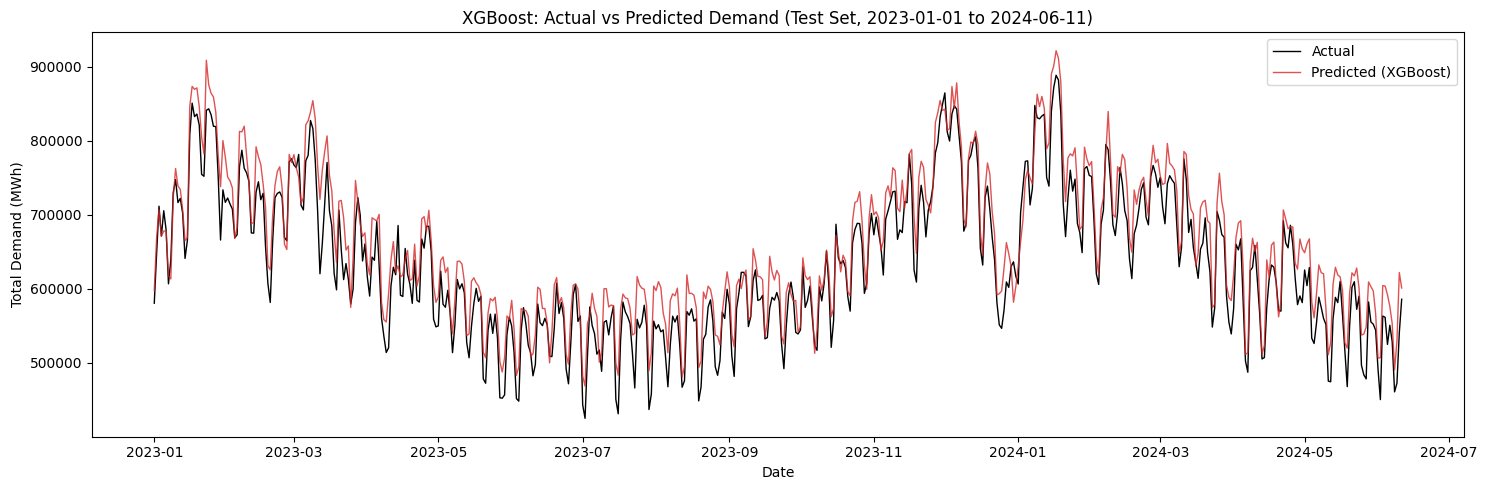

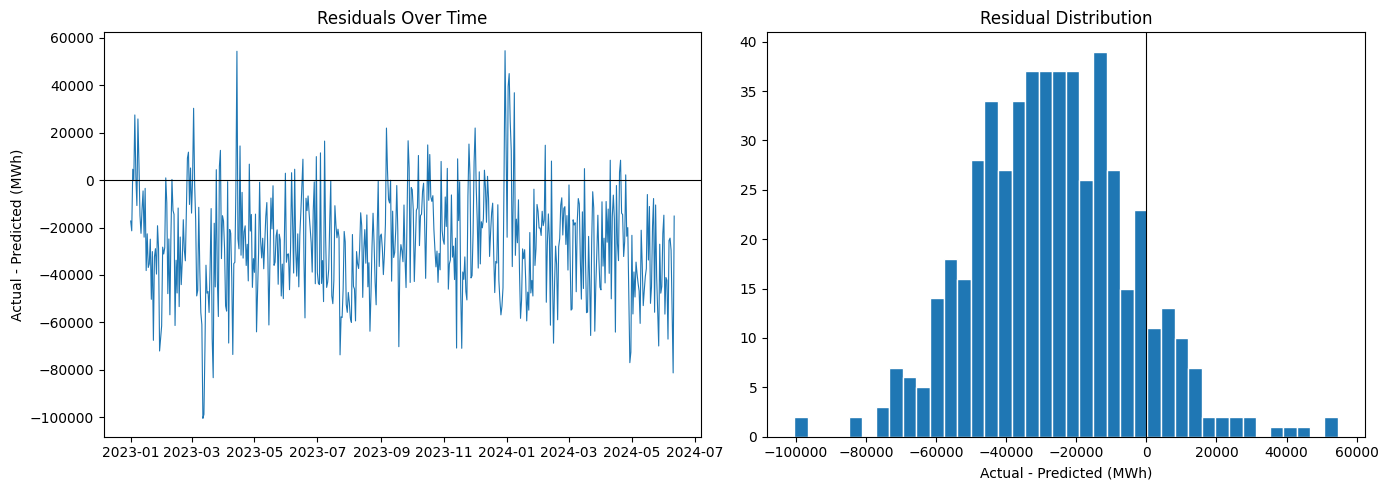


Residual summary: mean=-26,967, std=22,333, min=-100,461, max=54,584

Mean absolute % error by day type:
  Weekday: 4.76%
  Weekend: 5.19%
  Holiday: 7.49%
  Non-holiday: 4.81%

Saved step6_model_comparison.csv


In [9]:
# Step 6 - Evaluation (different metrics)

import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions on the held-out test set - the ONLY time this model sees test data
y_pred_final = final_model.predict(X_test)

# 2. Core metrics, using the same evaluate() function from Step 2 for consistency
print("Final tuned XGBoost performance on TEST set:\n")
results_final = evaluate(y_test, y_pred_final, "Tuned XGBoost (test)")

# 3. Fair head-to-head: all four models, same test set, same metric function
print("\n" + "="*70)
print("Full comparison - all evaluated on the SAME test set:\n")
comparison = pd.DataFrame([
    results_persistence, results_seasonal, results_final
])[['label', 'mae', 'rmse', 'mape']]
comparison.columns = ['Model', 'MAE', 'RMSE', 'MAPE (%)']

# Add % improvement over persistence baseline (the stronger of the two naive baselines)
persistence_mae = results_persistence['mae']
comparison['Improvement vs Persistence (%)'] = (
    (persistence_mae - comparison['MAE']) / persistence_mae * 100
).round(1)

print(comparison.to_string(index=False))

# 4. Actual vs Predicted over the full test period
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=1)
plt.plot(y_test.index, y_pred_final, label='Predicted (XGBoost)', color='tab:red', linewidth=1, alpha=0.8)
plt.title('XGBoost: Actual vs Predicted Demand (Test Set, 2023-01-01 to 2024-06-11)')
plt.xlabel('Date')
plt.ylabel('Total Demand (MWh)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_actual_vs_predicted.png', dpi=150)
plt.show()

# 5. Residual analysis: over time, and distribution
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_test.index, residuals, color='tab:blue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Actual - Predicted (MWh)')

axes[1].hist(residuals, bins=40, color='tab:blue', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Actual - Predicted (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step6_residuals.png', dpi=150)
plt.show()

print(f"\nResidual summary: mean={residuals.mean():,.0f}, std={residuals.std():,.0f}, "
      f"min={residuals.min():,.0f}, max={residuals.max():,.0f}")

# 6. Error breakdown by weekday/weekend and by holiday - checks whether the model
#    still struggles with the specific calendar effects identified back in Phase 2
error_df = pd.DataFrame({
    'abs_error': np.abs(residuals),
    'pct_error': np.abs(residuals / y_test.values) * 100,
    'is_weekend': X_test['is_weekend'].values,
    'is_holiday': X_test['is_holiday'].values
}, index=y_test.index)

print("\nMean absolute % error by day type:")
print(f"  Weekday: {error_df.loc[error_df['is_weekend']==0, 'pct_error'].mean():.2f}%")
print(f"  Weekend: {error_df.loc[error_df['is_weekend']==1, 'pct_error'].mean():.2f}%")
print(f"  Holiday: {error_df.loc[error_df['is_holiday']==1, 'pct_error'].mean():.2f}%")
print(f"  Non-holiday: {error_df.loc[error_df['is_holiday']==0, 'pct_error'].mean():.2f}%")

# 7. Save the comparison table for direct use in the report
comparison.to_csv(f'{OUTPUT_DIR}/step6_model_comparison.csv', index=False)
print("\nSaved step6_model_comparison.csv")

Quick check for whether the bias is getting worse over the time period of test set

In [10]:
# Quick check: does the bias get worse over the course of the test period?
# (supports the trend-extrapolation explanation if residuals trend more negative over time)
from scipy import stats
time_index = np.arange(len(residuals))
slope, intercept, r, p, se = stats.linregress(time_index, residuals)
print(f"Residual trend over test period: slope={slope:.2f} MWh/day, r={r:.3f}, p={p:.4g}")

Residual trend over test period: slope=-6.32 MWh/day, r=-0.043, p=0.3225


In [11]:
# Check whether the bias is stable within test, or shifts at a specific point
# (splits test into first half vs second half; if both halves have similar bias,
#  supports "constant offset from a level shift", not "still declining within test")
mid_point = len(residuals) // 2
print(f"Mean residual, first half of test:  {residuals[:mid_point].mean():,.0f}")
print(f"Mean residual, second half of test: {residuals[mid_point:].mean():,.0f}")

Mean residual, first half of test:  -28,120
Mean residual, second half of test: -25,814


# **Step 7 - SHAP explainability**

SHAP values computed for test set: (528, 20)


/tmp/ipykernel_3294/3869464609.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)


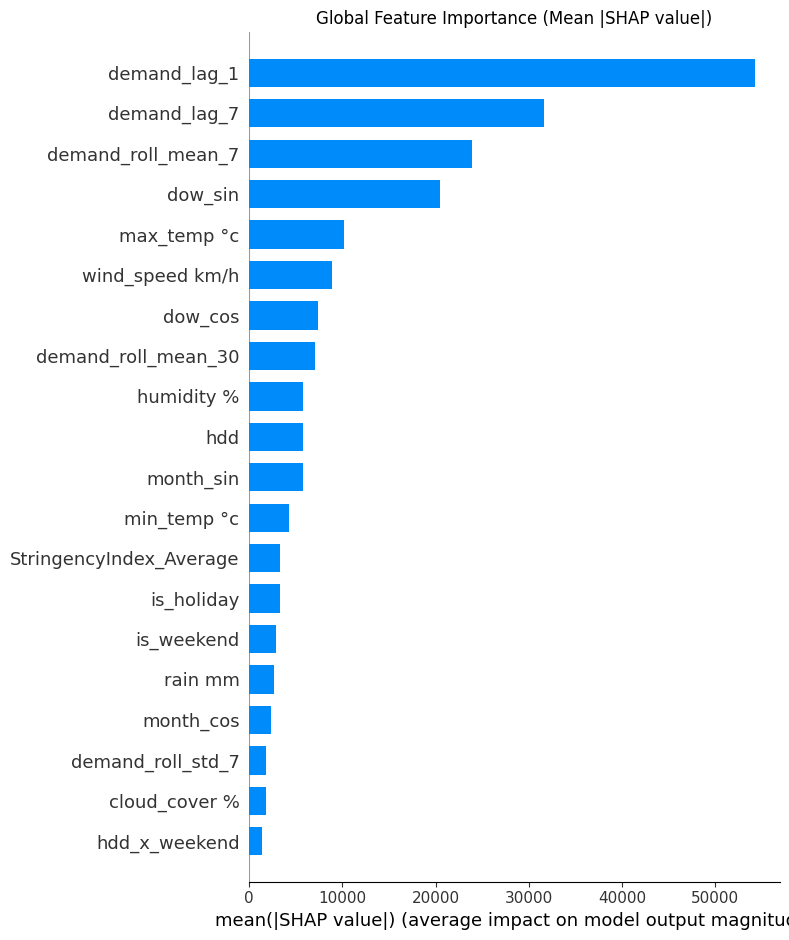

/tmp/ipykernel_3294/3869464609.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


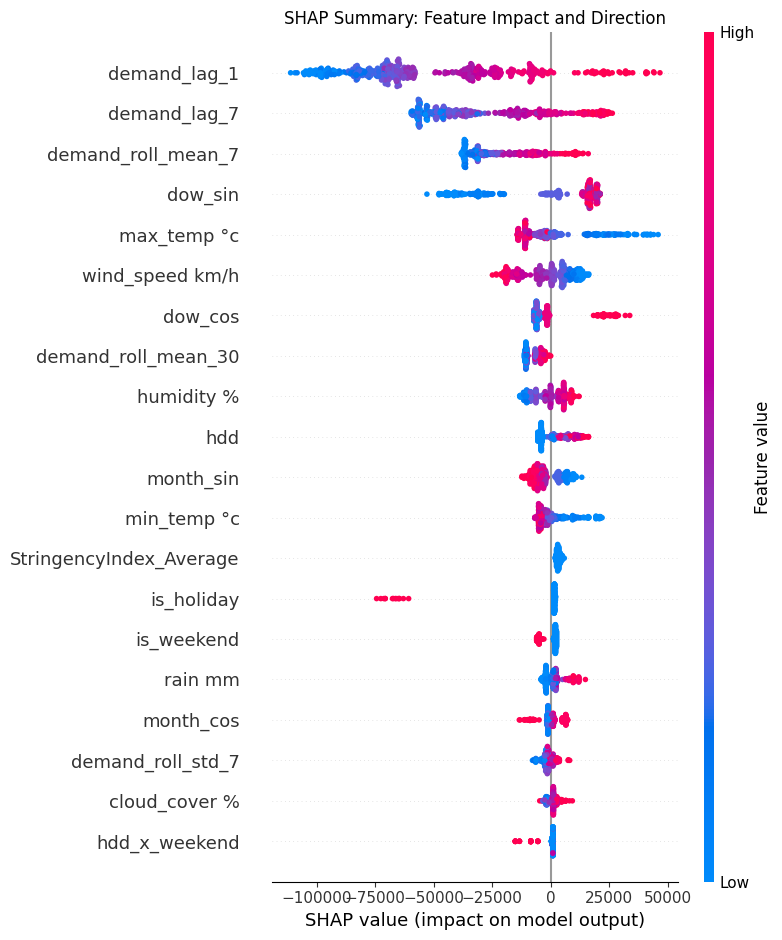

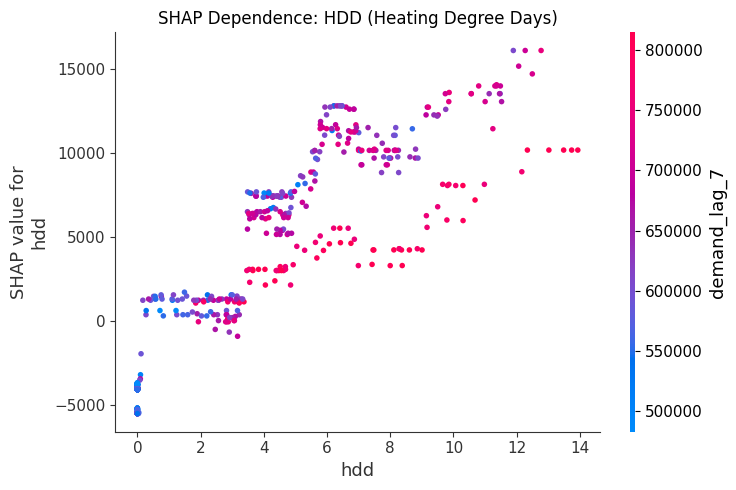


Local explanation example: 2023-01-02
Actual demand: 648,132 MWh
Predicted demand: 669,513 MWh


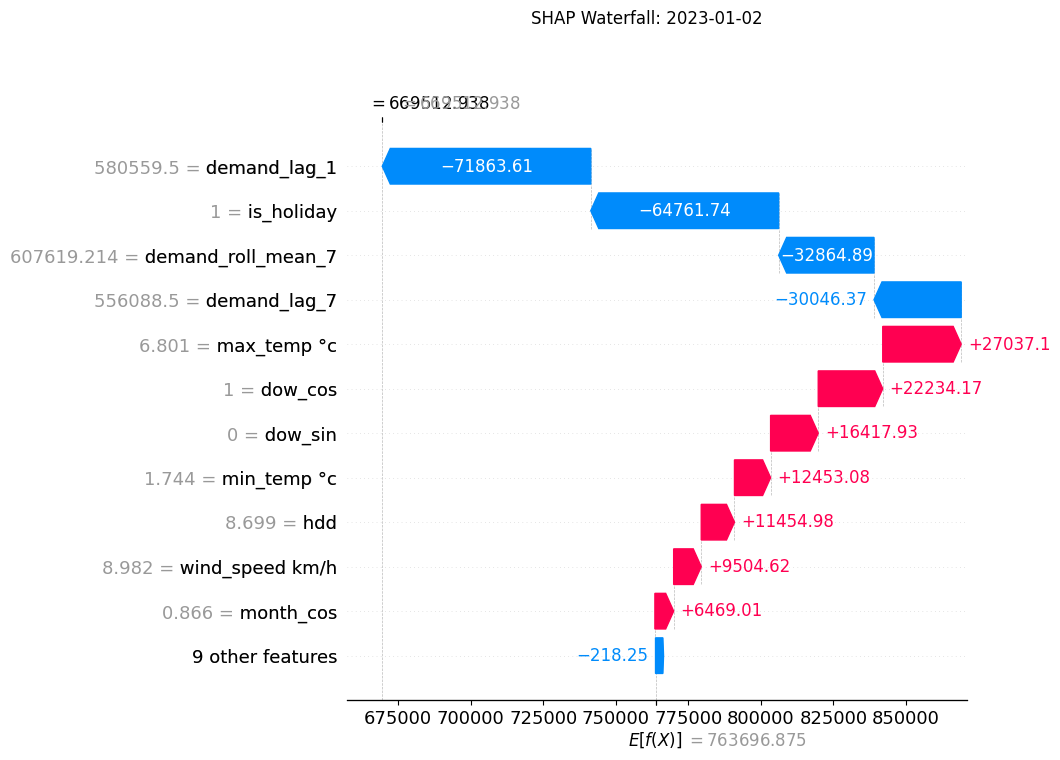


Top 10 features by mean |SHAP value|:
            feature  mean_abs_shap
       demand_lag_1   54266.597656
       demand_lag_7   31663.945312
 demand_roll_mean_7   23911.931641
            dow_sin   20458.505859
        max_temp °c   10193.810547
    wind_speed km/h    8894.720703
            dow_cos    7382.546387
demand_roll_mean_30    7018.177246
         humidity %    5816.148926
                hdd    5815.719238


In [12]:
# Step 7 - SHAP explainability

import shap
import matplotlib.pyplot as plt

# 1. TreeExplainer is the efficient, exact method for tree-based models like XGBoost
#    (no approximation needed, unlike KernelExplainer which you'd need for the LSTM later)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

print(f"SHAP values computed for test set: {shap_values.values.shape}")

# 2. Global feature importance - mean absolute SHAP value per feature, ranked
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step7_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Summary beeswarm plot
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary: Feature Impact and Direction')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step7_shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Dependence plot for the single strongest EXOGENOUS driver: hdd
shap.dependence_plot('hdd', shap_values.values, X_test, show=False)
plt.title('SHAP Dependence: HDD (Heating Degree Days)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step7_shap_dependence_hdd.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Local explanation
example_idx = X_test.index.get_loc(X_test[(X_test.index.month == 1) & (X_test['is_weekend'] == 0)].index[0])
example_date = X_test.index[example_idx]

print(f"\nLocal explanation example: {example_date.date()}")
print(f"Actual demand: {y_test.iloc[example_idx]:,.0f} MWh")
print(f"Predicted demand: {y_pred_final[example_idx]:,.0f} MWh")

original_figsize = plt.rcParams['figure.figsize']  # save so we can restore it after
plt.rcParams['figure.figsize'] = (12, 9)

shap.plots.waterfall(shap_values[example_idx], max_display=12, show=False)

fig = plt.gcf()
fig.suptitle(f'SHAP Waterfall: {example_date.date()}', y=1.03, fontsize=12)
plt.savefig(f'{OUTPUT_DIR}/step7_shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

plt.rcParams['figure.figsize'] = original_figsize  # restore default for any later plots in the notebook


# 6. Print the top 10 features by mean |SHAP value|, as a clean table for the report
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features by mean |SHAP value|:")
print(shap_importance.head(10).to_string(index=False))

# **Step 8 - Save the trained model + test prediction results**

In [13]:
# Step 8 - Save the trained model + test prediction results

import joblib
import json
from datetime import datetime

# 1. Save the trained model
joblib.dump(final_model, f'{OUTPUT_DIR}/xgboost_final_model.joblib')
print("Saved xgboost_final_model.joblib")

# 2. Save test set predictions alongside actuals
predictions_df = pd.DataFrame({
    'date': X_test.index,
    'actual': y_test.values,
    'predicted': y_pred_final,
    'residual': residuals
})
predictions_df.to_csv(f'{OUTPUT_DIR}/xgboost_test_predictions.csv', index=False)
print("Saved xgboost_test_predictions.csv")

# 3. Save the model comparison table
comparison.to_csv(f'{OUTPUT_DIR}/xgboost_model_comparison.csv', index=False)
print("Saved xgboost_model_comparison.csv")

# 4. Save a small metadata file documenting exactly how this model was produced
metadata = {
    'model_type': 'XGBoost (XGBRegressor)',
    'xgboost_version': xgb.__version__,
    'random_seed': SEED,
    'hyperparameters': {
        'max_depth': best_params['max_depth'],
        'eta': best_params['eta'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'n_estimators': best_n_estimators
    },
    'training_data': 'train + validation combined (2009-01-31 to 2022-12-31)',
    'training_rows': int(X_trainval.shape[0]),
    'test_period': f"{X_test.index.min().date()} to {X_test.index.max().date()}",
    'test_rows': int(X_test.shape[0]),
    'final_training_time_seconds': round(final_train_time, 3),
    'test_set_metrics': {
        'mae': round(float(results_final['mae']), 2),
        'rmse': round(float(results_final['rmse']), 2),
        'mape': round(float(results_final['mape']), 3)
    },
    'saved_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(f'{OUTPUT_DIR}/xgboost_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Saved xgboost_model_metadata.json")

# 5. Final confirmation printout
print("\n--- Modelling_XGBoost.ipynb complete ---")
print(f"Final test MAPE: {results_final['mape']:.2f}%  "
      f"(vs. persistence baseline: {results_persistence['mape']:.2f}%)")
print("Artifacts saved: xgboost_final_model.joblib, xgboost_test_predictions.csv, "
      "xgboost_model_comparison.csv, xgboost_model_metadata.json")

Saved xgboost_final_model.joblib
Saved xgboost_test_predictions.csv
Saved xgboost_model_comparison.csv
Saved xgboost_model_metadata.json

--- Modelling_XGBoost.ipynb complete ---
Final test MAPE: 4.88%  (vs. persistence baseline: 5.87%)
Artifacts saved: xgboost_final_model.joblib, xgboost_test_predictions.csv, xgboost_model_comparison.csv, xgboost_model_metadata.json


# **Additional I - Baseline size/latency/complexity metrics (for Model Compression comparison)**

In [14]:
# Quick addition: baseline size/latency/complexity metrics for the compression comparison later


import os
import time

# 1. Model file size on disk
model_size_kb = os.path.getsize(f'{OUTPUT_DIR}/xgboost_final_model.joblib') / 1024
print(f"Model file size: {model_size_kb:.1f} KB")

# 2. Inference latency - average time per prediction, measured over many repeats
#    for stability (a single prediction is too fast/noisy to time reliably)
n_repeats = 100
start = time.time()
for _ in range(n_repeats):
    _ = final_model.predict(X_test)
elapsed = time.time() - start
avg_inference_time_ms = (elapsed / n_repeats) * 1000
avg_inference_time_per_row_us = (elapsed / n_repeats / len(X_test)) * 1_000_000

print(f"Average inference time (full test set, {len(X_test)} rows): {avg_inference_time_ms:.2f} ms")
print(f"Average inference time per row: {avg_inference_time_per_row_us:.2f} µs")

# 3. Model complexity: total number of tree leaves (a concrete, compression-comparable number)
booster_df = final_model.get_booster().trees_to_dataframe()
total_leaves = (booster_df['Feature'] == 'Leaf').sum()
total_nodes = len(booster_df)
print(f"Total trees: {final_model.get_booster().num_boosted_rounds()}")
print(f"Total nodes across all trees: {total_nodes}")
print(f"Total leaves across all trees: {total_leaves}")

# 4. Append these to the metadata JSON already saved in Step 8
with open(f'{OUTPUT_DIR}/xgboost_model_metadata.json', 'r') as f:
    metadata = json.load(f)

metadata['compression_baseline'] = {
    'model_size_kb': round(model_size_kb, 1),
    'avg_inference_time_ms_full_test_set': round(avg_inference_time_ms, 3),
    'avg_inference_time_per_row_us': round(avg_inference_time_per_row_us, 3),
    'total_trees': final_model.get_booster().num_boosted_rounds(),
    'total_nodes': int(total_nodes),
    'total_leaves': int(total_leaves)
}

with open(f'{OUTPUT_DIR}/xgboost_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("\nUpdated xgboost_model_metadata.json with compression baseline metrics")

Model file size: 118.2 KB
Average inference time (full test set, 528 rows): 1.67 ms
Average inference time per row: 3.17 µs
Total trees: 122
Total nodes across all trees: 854
Total leaves across all trees: 488

Updated xgboost_model_metadata.json with compression baseline metrics


# **Additional II - Bias and Mitigation Analysis**

In [15]:
# Additional - Bias and Mitigation Analysis

# 1. Signed bias (not just absolute error) by day type and month - reveals DIRECTION
signed_bias_df = pd.DataFrame({
    'residual': residuals,  # actual - predicted; negative = model over-predicts
    'is_weekend': X_test['is_weekend'].values,
    'is_holiday': X_test['is_holiday'].values,
    'month': test.index.month
}, index=y_test.index)

print("Mean signed residual (actual - predicted) by day type:")
print(f"  Weekday:     {signed_bias_df.loc[signed_bias_df['is_weekend']==0,'residual'].mean():>10,.0f}")
print(f"  Weekend:     {signed_bias_df.loc[signed_bias_df['is_weekend']==1,'residual'].mean():>10,.0f}")
print(f"  Holiday:     {signed_bias_df.loc[signed_bias_df['is_holiday']==1,'residual'].mean():>10,.0f}")
print(f"  Non-holiday: {signed_bias_df.loc[signed_bias_df['is_holiday']==0,'residual'].mean():>10,.0f}")

print("\nMean signed residual by month (reveals any seasonal bias pattern):")
print(signed_bias_df.groupby('month')['residual'].mean().round(0))

# 2. Simple bias-correction mitigation: shift predictions by the mean residual
#    observed on VALIDATION (not test - keeps test genuinely unseen for the correction itself)
y_pred_val_final = final_model.predict(X_val)
val_residuals = y_val.values - y_pred_val_final
bias_correction = val_residuals.mean()
print(f"\nBias correction constant (mean validation residual): {bias_correction:,.0f}")

y_pred_corrected = y_pred_final + bias_correction

print("\nPerformance BEFORE vs AFTER simple bias correction (on test set):")
evaluate(y_test, y_pred_final, "XGBoost (uncorrected)")
evaluate(y_test, y_pred_corrected, "XGBoost (bias-corrected)")

Mean signed residual (actual - predicted) by day type:
  Weekday:        -27,418
  Weekend:        -25,840
  Holiday:        -40,042
  Non-holiday:    -26,610

Mean signed residual by month (reveals any seasonal bias pattern):
month
1    -22662.0
2    -24639.0
3    -33446.0
4    -25502.0
5    -33302.0
6    -27043.0
7    -34683.0
8    -35300.0
9    -20717.0
10   -16527.0
11   -26333.0
12   -18008.0
Name: residual, dtype: float64

Bias correction constant (mean validation residual): -3,098

Performance BEFORE vs AFTER simple bias correction (on test set):
XGBoost (uncorrected)      MAE=    29,691  RMSE=    35,014  MAPE=  4.88%
XGBoost (bias-corrected)   MAE=    27,371  RMSE=    32,688  MAPE=  4.50%


{'label': 'XGBoost (bias-corrected)',
 'mae': np.float64(27371.456447339424),
 'rmse': np.float64(32687.633487888328),
 'mape': np.float64(4.497935382285535)}

In [16]:
# 3. Identify the single largest residuals (over-prediction and under-prediction)
#    - lets us check whether XGBoost's worst day coincides with LSTM's (12 March 2023),
#      which would point to a shared, real-world data anomaly rather than a model-specific quirk

worst_over_idx = signed_bias_df['residual'].idxmin()   # most negative = worst over-prediction
worst_under_idx = signed_bias_df['residual'].idxmax()  # most positive = worst under-prediction

print("Single worst over-prediction (most negative residual):")
print(f"  Date: {worst_over_idx.date()}  ({worst_over_idx.strftime('%A')})")
print(f"  Actual: {y_test.loc[worst_over_idx]:,.0f} MWh")
print(f"  Predicted: {y_pred_final[y_test.index.get_loc(worst_over_idx)]:,.0f} MWh")
print(f"  Residual: {signed_bias_df.loc[worst_over_idx, 'residual']:,.0f} MWh")
print(f"  is_weekend={signed_bias_df.loc[worst_over_idx, 'is_weekend']}, "
      f"is_holiday={signed_bias_df.loc[worst_over_idx, 'is_holiday']}")

print("\nSingle worst under-prediction (most positive residual):")
print(f"  Date: {worst_under_idx.date()}  ({worst_under_idx.strftime('%A')})")
print(f"  Actual: {y_test.loc[worst_under_idx]:,.0f} MWh")
print(f"  Predicted: {y_pred_final[y_test.index.get_loc(worst_under_idx)]:,.0f} MWh")
print(f"  Residual: {signed_bias_df.loc[worst_under_idx, 'residual']:,.0f} MWh")
print(f"  is_weekend={signed_bias_df.loc[worst_under_idx, 'is_weekend']}, "
      f"is_holiday={signed_bias_df.loc[worst_under_idx, 'is_holiday']}")

Single worst over-prediction (most negative residual):
  Date: 2023-03-12  (Sunday)
  Actual: 620,336 MWh
  Predicted: 720,797 MWh
  Residual: -100,461 MWh
  is_weekend=1, is_holiday=0

Single worst under-prediction (most positive residual):
  Date: 2023-12-30  (Saturday)
  Actual: 636,442 MWh
  Predicted: 581,858 MWh
  Residual: 54,584 MWh
  is_weekend=1, is_holiday=0


In [17]:
# Top 3 worst over-predictions and under-predictions, not just the single worst
N_TOP = 3
sorted_dates = signed_bias_df['residual'].sort_values().index  # ascending: most negative (over-prediction) first

print(f"Top {N_TOP} worst over-predictions (most negative residuals):")
for rank, d in enumerate(sorted_dates[:N_TOP], start=1):
    idx = y_test.index.get_loc(d)
    print(f"  #{rank}: {d.date()} ({d.strftime('%A')})  residual={signed_bias_df.loc[d,'residual']:,.0f} MWh  "
          f"actual={y_test.loc[d]:,.0f}  predicted={y_pred_final[idx]:,.0f}  "
          f"is_weekend={signed_bias_df.loc[d,'is_weekend']}  is_holiday={signed_bias_df.loc[d,'is_holiday']}")

print(f"\nTop {N_TOP} worst under-predictions (most positive residuals):")
for rank, d in enumerate(sorted_dates[::-1][:N_TOP], start=1):
    idx = y_test.index.get_loc(d)
    print(f"  #{rank}: {d.date()} ({d.strftime('%A')})  residual={signed_bias_df.loc[d,'residual']:,.0f} MWh  "
          f"actual={y_test.loc[d]:,.0f}  predicted={y_pred_final[idx]:,.0f}  "
          f"is_weekend={signed_bias_df.loc[d,'is_weekend']}  is_holiday={signed_bias_df.loc[d,'is_holiday']}")

Top 3 worst over-predictions (most negative residuals):
  #1: 2023-03-12 (Sunday)  residual=-100,461 MWh  actual=620,336  predicted=720,797  is_weekend=1  is_holiday=0
  #2: 2023-03-13 (Monday)  residual=-98,778 MWh  actual=661,522  predicted=760,300  is_weekend=0  is_holiday=0
  #3: 2023-03-22 (Wednesday)  residual=-83,314 MWh  actual=612,418  predicted=695,732  is_weekend=0  is_holiday=0

Top 3 worst under-predictions (most positive residuals):
  #1: 2023-12-30 (Saturday)  residual=54,584 MWh  actual=636,442  predicted=581,858  is_weekend=1  is_holiday=0
  #2: 2023-04-14 (Friday)  residual=54,346 MWh  actual=685,477  predicted=631,131  is_weekend=0  is_holiday=0
  #3: 2024-01-03 (Wednesday)  residual=44,939 MWh  actual=737,602  predicted=692,663  is_weekend=0  is_holiday=0


In [18]:
# Re-measure inference timing a second time, to check if the earlier reading was noisy
import time
start = time.time()
for _ in range(20):
    _ = final_model.predict(X_test)
elapsed = time.time() - start
print(f"Re-measured avg inference time per row: {(elapsed/20/len(X_test))*1_000_000:.2f} µs")

Re-measured avg inference time per row: 3.63 µs
